# Gamaka Floor — Raga Pitch-Contour Study: Report

**A deep generative models study.** Carnatic raga identity lives
substantially in the *continuous* pitch contour (gamaka / ornamentation), not
just the discrete note set. The spine of this project is a **quantisation
study**: how far can pitch resolution be coarsened, from continuous cents down
to 12 semitones, before a raga classifier collapses? That curve quantifies how
much raga identity sits below the note level. Two smaller pieces sit on top: an
allied-raga contrast (dropped, see §4) and an optional proof-of-concept
generator of pitch contours (§5).

This notebook collects every figure, table, and number produced by
`00_data_audit` → `04_generator` into one narrative. It does not recompute
anything — every number below is read from `artifacts/numbers.json` and the
per-milestone CSVs those notebooks wrote. **Musical interpretation is grounded
in documented Carnatic theory (academic sources, cited inline), not the
owner's personal ear-training** — he does not have a Carnatic music background
(CLAUDE.md corrected 2026-08-29). Every interpretive claim below is sourced and
hedged; where documentation is thin, absent, or contradicts the data, that is
stated plainly rather than smoothed over.

In [1]:
import os, sys, json, io
sys.path.insert(0, os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd())=="notebooks" else os.getcwd())
import pandas as pd
from IPython.display import Image, display, Markdown

BASE = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd())=="notebooks" else os.getcwd()
ART = os.path.join(BASE, "artifacts")
FIG = os.path.join(ART, "figures")

with open(os.path.join(ART, "numbers.json"), encoding="utf-8") as f:
    N = json.load(f)

def show(fname, width=760):
    display(Image(filename=os.path.join(FIG, fname), width=width))

def table(csv_name, **kw):
    return pd.read_csv(os.path.join(ART, csv_name), encoding="utf-8", **kw)

pd.set_option("display.width", 160)
print("Milestones present in numbers.json:", list(N.keys()))

Milestones present in numbers.json: ['m0', 'm1', 'm2', 'm3', 'm4', 'm5', 'm6']


## 1. Data & the artist confound

**Dataset:** Saraga Carnatic 1.5 (CC BY-NC-SA 4.0, Zenodo record 4301737). Only
text pitch/section/metadata annotations are used, not audio. See §7 for the
full licence note.

**The constraint that shapes every claim in this project (CLAUDE.md):** artist
identity is a first-class confound. Only 4 ragas clear "≥15 min alapana, ≥2
artists," and two of those are effectively single-voice once you look at the
per-artist split. Only **Karaharapriya** and **Mōhanaṁ** are genuinely
artist-balanced — this is why the generator (§5) trains on exactly those two.

In [2]:
cov_a = table("coverage_alapana.csv")
cov_a

,raga,alap_min,artists,recs
0,Karaharapriya,24.675,2,2
1,Mōhanaṁ,18.860,2,2
2,Ṣanmukhapriya,17.704,2,2
3,Kāṁbhōji,16.954,1,1
4,Bhairavi,15.039,2,2
5,Harikāmbhōji,13.289,2,2
6,Tōḍi,12.781,3,3
7,Kāpi,12.334,1,1
8,Sāvēri,10.575,1,1
9,Kamās,10.572,2,2


**Composition (kriti) confound**, for metered sections: two recordings of the
same composition in the same raga let a classifier learn the song, not the
raga. Alapana is exempt (unmetered, no fixed melody). M1 found two ragas in the
all-vocal-sections pool that pass the artist-balance bar but fail composition
diversity (Saurāṣtraṁ: 6 recordings, all the same mangalam; Jōnpuri: 2
compositions/3 recordings) — both excluded from M2's primary pool.

In [3]:
m0, m1 = N["m0"], N["m1"]
print(f"{m0['n_metadata_json']} recordings total, {m0['n_raga_labelled']} raga-labelled, "
      f"{m0['n_quant_distinct_ragas']} distinct ragas, {m0['n_ragas_ge2rec_ge2artist']} usable for quantisation "
      f"(>=2 recordings, >=2 artists).")
print(f"M1 corpora: {m1['alapana_corpus_segments']} alapana segments ({m1['alapana_corpus_ragas']}), "
      f"{m1['allsections_corpus_segments']} all-vocal-sections segments across "
      f"{m1['primary_m2_pool_size']} primary + {m1['secondary_m2_pool_size']} secondary ragas.")
print(f"Composition-degenerate ragas excluded from the primary pool: {m1['composition_degenerate_ragas']}")

249 recordings total, 184 raga-labelled, 96 distinct ragas, 42 usable for quantisation (>=2 recordings, >=2 artists).
M1 corpora: 8 alapana segments (['Bhairavi', 'Karaharapriya', 'Mōhanaṁ', 'Ṣanmukhapriya']), 526 all-vocal-sections segments across 12 primary + 40 secondary ragas.
Composition-degenerate ragas excluded from the primary pool: ['Jōnpuri', 'Saurāṣtraṁ']


> **Your read:** _(nothing needed here — this section is purely descriptive of
> the data constraints, not a claim about the music)._

---
## 2. Quantisation study — THE SPINE (Milestone 2)

Folded pitch-class contours (`cents % 1200`), windowed at 4s/4s hop,
classified at four resolutions (10c standing in for continuous, 20c, 50c,
semitone/100c) with `LogisticRegression(class_weight="balanced", C=10)` —
the standard classifier for this project after an unweighted fit was found to
starve rare classes (see `status/STATUS_M2.md`). Five configs: alapana (4
ragas) and all-vocal-sections primary-12/secondary-40 pools, each with
recording-, artist-, and/or composition-grouped CV where feasible.

**Theoretical grounding for the core hypothesis.** Krishna, T.M. & Ishwar, V.
(2012), ["Carnatic music: Svara, Gamaka, Motif and Raga identity"](https://www.semanticscholar.org/paper/Carnatic-music:-Svara,-Gamaka,-Motif-and-Raga-Krishna-Ishwar/41baaa7e8b8b1dd9a4c830a4ae1f917d16caa69c),
2nd CompMusic Workshop — coauthored by a researcher from the same CompMusic
project that built the Saraga dataset used here — argues that two ragas can
share the same constituent pitch positions and be told apart specifically by
their gamakas and characteristic phrases (sañcāras). That is precisely the
claim this quantisation curve tests empirically. *(Caveat: the paper's PDF was
access-blocked when checked; this is from the paper's indexed abstract, not a
verified direct quote.)*

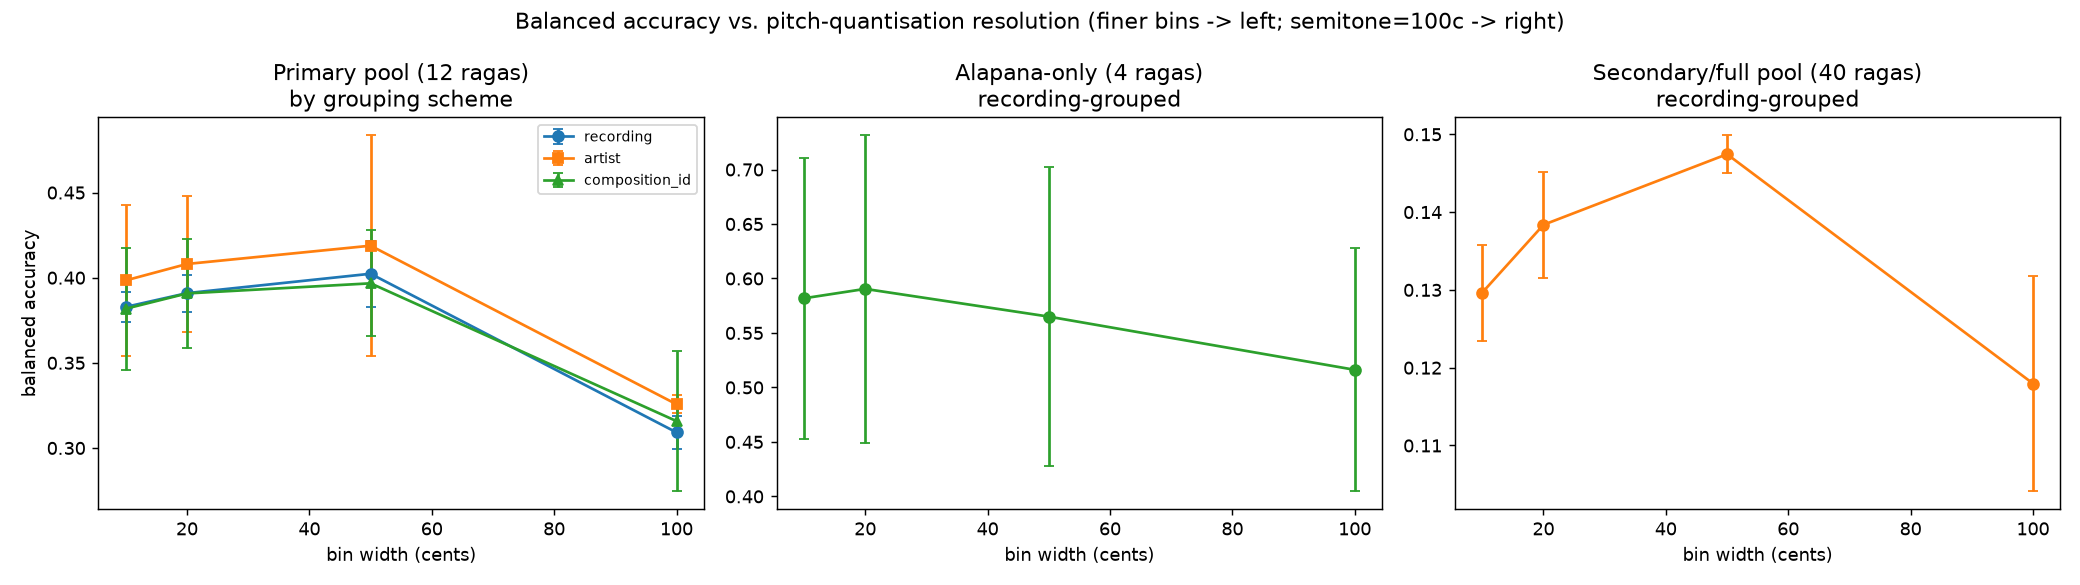

In [4]:
show("m2_accuracy_vs_resolution.png")

In [5]:
rows = []
m2 = N["m2"]
for key, label in [
    ("alapana_recording_grouped", "alapana / 4 ragas / recording"),
    ("primary12_recording_grouped", "allsections / primary-12 / recording"),
    ("primary12_artist_grouped", "allsections / primary-12 / artist"),
    ("primary12_composition_grouped", "allsections / primary-12 / composition"),
    ("secondary40_recording_grouped", "allsections / secondary-40 / recording"),
]:
    r = {"config": label}
    for res_label, d in m2[key].items():
        r[res_label] = f"{d['bal_acc_mean']:.3f} ± {d['bal_acc_std']:.3f}"
    rows.append(r)
pd.DataFrame(rows).set_index("config")

,continuous (10c),20c,50c,semitone (100c)
config,,,,
alapana / 4 ragas / recording,0.582 ± 0.129,0.590 ± 0.141,0.565 ± 0.137,0.516 ± 0.111
allsections / primary-12 / recording,0.383 ± 0.009,0.391 ± 0.011,0.402 ± 0.019,0.309 ± 0.010
allsections / primary-12 / artist,0.398 ± 0.044,0.408 ± 0.040,0.419 ± 0.065,0.326 ± 0.005
allsections / primary-12 / composition,0.382 ± 0.036,0.391 ± 0.032,0.397 ± 0.031,0.316 ± 0.041
allsections / secondary-40 / recording,0.130 ± 0.006,0.138 ± 0.007,0.147 ± 0.002,0.118 ± 0.014


**Pattern, stated factually (from `status/STATUS_M2.md`):** all five configs
show the same shape — roughly flat, or mildly rising, from continuous through
50c, then a real drop at semitone. The drop is most confident (small std
relative to the gap) in the artist-grouped and composition-grouped primary-12
runs and in the secondary-40 pool. The effect concentrates at the last,
coarsest step rather than a smooth decline from the start.

**Per-raga degradation ranking** (primary-12 pool, recording-grouped,
out-of-fold recall at continuous vs. semitone) — the generalised substitute
for the allied-pair contrast (§4):

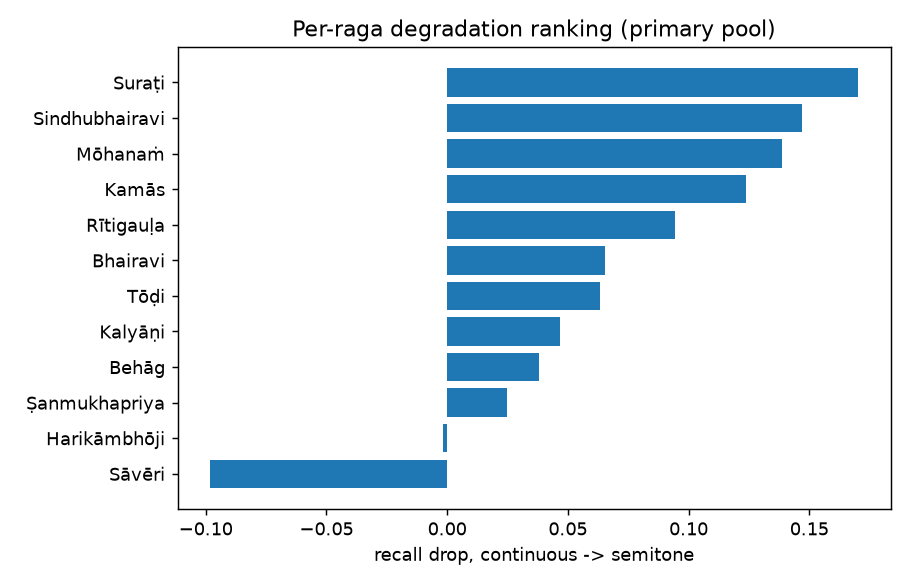

,raga,recall_continuous,recall_semitone,drop
0,Suraṭi,0.441489,0.271277,0.170213
1,Sindhubhairavi,0.464706,0.317647,0.147059
2,Mōhanaṁ,0.433486,0.294725,0.138761
3,Kamās,0.497283,0.373641,0.123641
4,Rītigauḷa,0.197708,0.103152,0.094556
5,Bhairavi,0.449564,0.384184,0.065380
6,Tōḍi,0.432542,0.369427,0.063115
7,Kalyāṇi,0.131579,0.085020,0.046559
8,Behāg,0.377119,0.338983,0.038136
9,Ṣanmukhapriya,0.432449,0.407773,0.024676


In [6]:
show("m2_raga_degradation_ranking.png")
table("m2_raga_degradation_ranking.csv")

9 of 12 ragas show a positive drop. Behāg and Rītigauḷa are essentially flat.
Sāvēri is a clear outlier in the other direction (recall *improves* at
semitone resolution) — flagged in M2, never resolved.

**Interpretation, checked against documented Carnatic theory (not personal
listening — see note above).** Matching the degradation ranking to
per-raga theory descriptions found via research gives a partial, honest
correspondence, not a clean confirmed story:

- **Matches.** [Mōhanaṁ](https://www.spardhaschoolofmusic.com/blog/raga-mohanam-in-carnatic-music-a-gateway-to-joy)
  (0.139 drop) is explicitly described as *"sarva svara gamaka varika rakti
  raga"* — every one of its five notes is meant to be rendered with gamaka,
  despite being pentatonic. [Sindhubhairavi](https://en.wikipedia.org/wiki/Sindhu_Bhairavi_(raga))
  (0.147) is a *bhashanga* raga using nearly the full 12-semitone palette, the
  most chromatically flexible raga in this pool — consistent with losing the
  most when forced onto a fixed 12-tone grid. At the low end,
  [Harikāmbhōji](https://en.wikipedia.org/wiki/Harikambhoji) (≈0 drop) is the
  one raga here with no documented *bhashanga*, *vakra*, or special-gamaka
  commentary found anywhere — a plain reference scale, and notably the
  melakarta parent of Mōhanaṁ, Kamās, and Suraṭi as janya ragas.
- **Doesn't match.** [Sāvēri](https://en.wikipedia.org/wiki/Saveri) is a clear
  counterexample: documented in the *same* "gamaka varika rakti" category as
  Mōhanaṁ, yet its recall *improves* at coarse (semitone) resolution — the
  opposite of what the theory-based hypothesis predicts. No source found
  explains this. Stated here as an open disagreement between documented theory
  and this empirical result, not explained away — and worth checking
  separately whether it's a comps=3 small-sample artifact (comps sits right at
  the primary-pool floor) before reading too much into either direction.
- **Thin or missing evidence.** [Suraṭi](https://sriramv.com/2013/04/03/surutti/)
  (largest drop, 0.170) and [Rītigauḷa](https://en.wikipedia.org/wiki/Reetigowla)
  (0.095) have suggestive-but-not-explicit documentation (long ornamented
  *karvais*; a zigzag arohana structure, respectively). [Kamās](https://www.parrikar.org/carnatic/khamaj-page2/)
  (0.124) has essentially no gamaka-specific documentation available in the
  sources checked — an honest gap, not a claim either way.

**Bottom line:** melakarta "parent scale" ragas with plain, undecorated
structure trend toward less semitone-quantisation damage; janya ragas
explicitly documented as heavily gamaka-dependent trend toward more. But it's
a partial correspondence with one direct, unexplained counterexample
(Sāvēri), not a confirmed causal story — present it in the report with that
hedge intact.

---
## 3. Allied pair — documented drop (Milestone 3)

An allied-raga contrast (two ragas sharing a note set, differing in gamaka)
needs an artist-balanced pair on both sides, or any separation found is
equally explainable by singer identity. M0 searched the full 96-raga
collection; no candidate survived the balance constraint.

In [7]:
candidates = pd.DataFrame([
    dict(pair="Suraṭi / Kēdāgauḷa", verdict="fails -- Suraṭi single-artist"),
    dict(pair="Kāṃbhōji / Harikāṃbhōji", verdict="fails -- same lead artist dominates both sides"),
    dict(pair="Ābhōgi / Śrīranjani", verdict="fails -- thin on both sides"),
    dict(pair="Bēgaḍa / Śankarābharaṇaṃ", verdict="fails -- Śankarābharaṇaṃ single-artist"),
    dict(pair="Kalyāṇi / Hamīr kaḷyaṇi", verdict="fails -- both single-artist"),
])
m3 = N["m3"]
print(f"Decision: {m3['decision']}. {m3['n_balanced_ragas_no_ally']} well-balanced ragas found "
      f"collection-wide; none form an allied pair with each other.")
candidates

Decision: dropped. 18 well-balanced ragas found collection-wide; none form an allied pair with each other.


,pair,verdict
0,Suraṭi / Kēdāgauḷa,fails -- Suraṭi single-artist
1,Kāṃbhōji / Harikāṃbhōji,fails -- same lead artist dominates both sides
2,Ābhōgi / Śrīranjani,fails -- thin on both sides
3,Bēgaḍa / Śankarābharaṇaṃ,fails -- Śankarābharaṇaṃ single-artist
4,Kalyāṇi / Hamīr kaḷyaṇi,fails -- both single-artist


**Substitute:** §2's per-raga degradation ranking, reused without
recomputation — it generalises the same claim (gamaka-dependent ragas should
degrade harder under coarsening) across the whole pool instead of one
hand-picked pair, without needing artist balance.

**Disclosed gap:** no leave-one-artist-out check was ever run, because no pair
qualified to run it on. This is not equivalent to spec's ideal M3 acceptance
criterion — say so plainly in any write-up, don't present the ranking as an
artist-controlled substitute.

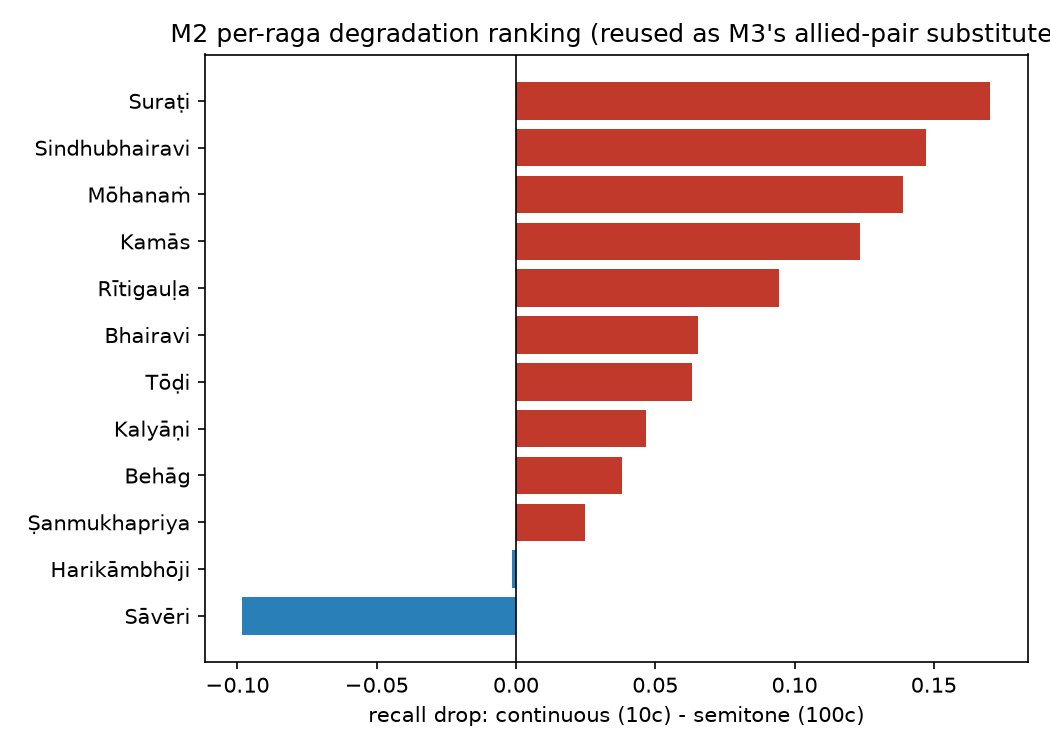

In [8]:
show("m3_degradation_ranking_reuse.png")

**Interpretation.** This decision doesn't depend on personal musical
expertise the way §2/§4 do — M0's search was exhaustive over the full 96-raga
collection using an objective balance criterion (≥2 artists, ≥4 vocal-min
each), not a subjective/theory judgement call, and no candidate pair passed on
both sides. Dropping the allied-pair experiment stands as the correct call
given that constraint.

---
## 4. Generator proof-of-concept (Milestones 4–5)

Small conditional GRU language model (56,917 params) over lightly quantised,
unfolded, cleaned pitch, trained on the two artist-balanced alapana ragas
(Karaharapriya, Mōhanaṁ). Trained on **re-extracted contiguous voiced runs**
(not the M1 corpus files, which splice across dropped unvoiced frames — fine
for M2's order-invariant histograms, wrong for a sequence model). AR-over-
quantised-pitch was chosen directly rather than attempted-then-fell-back-from
diffusion, because this environment is CPU-only and spec.md permits picking
whichever trains stably first when that constraint is known up front.

56,917 params, cpu, 2.0s windows @ 114.8 Hz, 133-token vocab (25.0c bins).
Windows: {'Karaharapriya': 538, 'Mōhanaṁ': 396}
Training loss: 4.273 -> 0.921 over 35 epochs (chance = 4.890). Diverged: False.


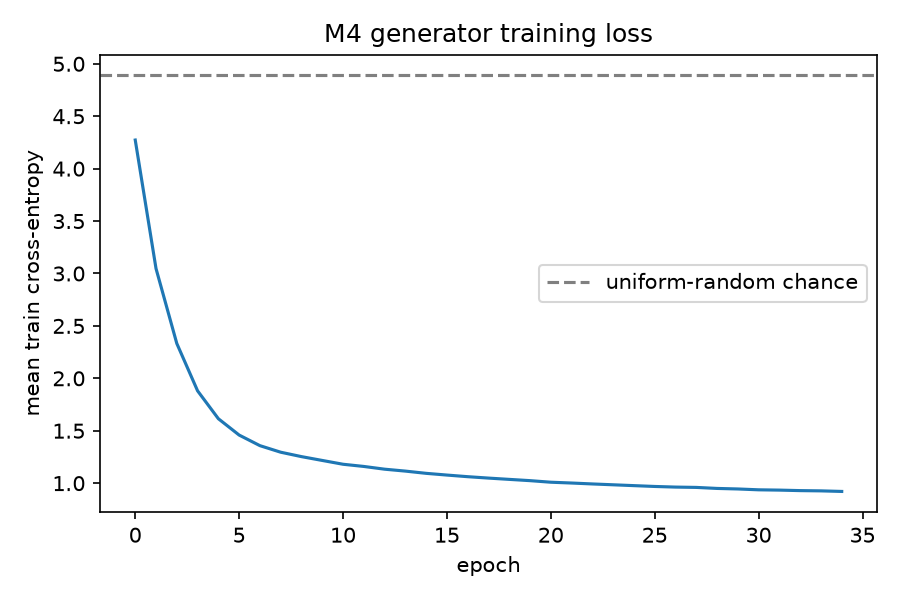

In [9]:
m4 = N["m4"]
print(f"{m4['n_params']:,} params, {m4['device']}, {m4['window_sec']}s windows @ "
      f"{m4['decimated_fps']:.1f} Hz, {m4['vocab_size']}-token vocab ({m4['bin_width_cents']}c bins).")
print(f"Windows: {m4['n_windows_per_raga']}")
print(f"Training loss: {m4['loss_start']:.3f} -> {m4['loss_end']:.3f} over {m4['epochs']} epochs "
      f"(chance = {m4['loss_chance_level']:.3f}). Diverged: {m4['diverged']}.")
show("m4_training_loss.png", width=500)

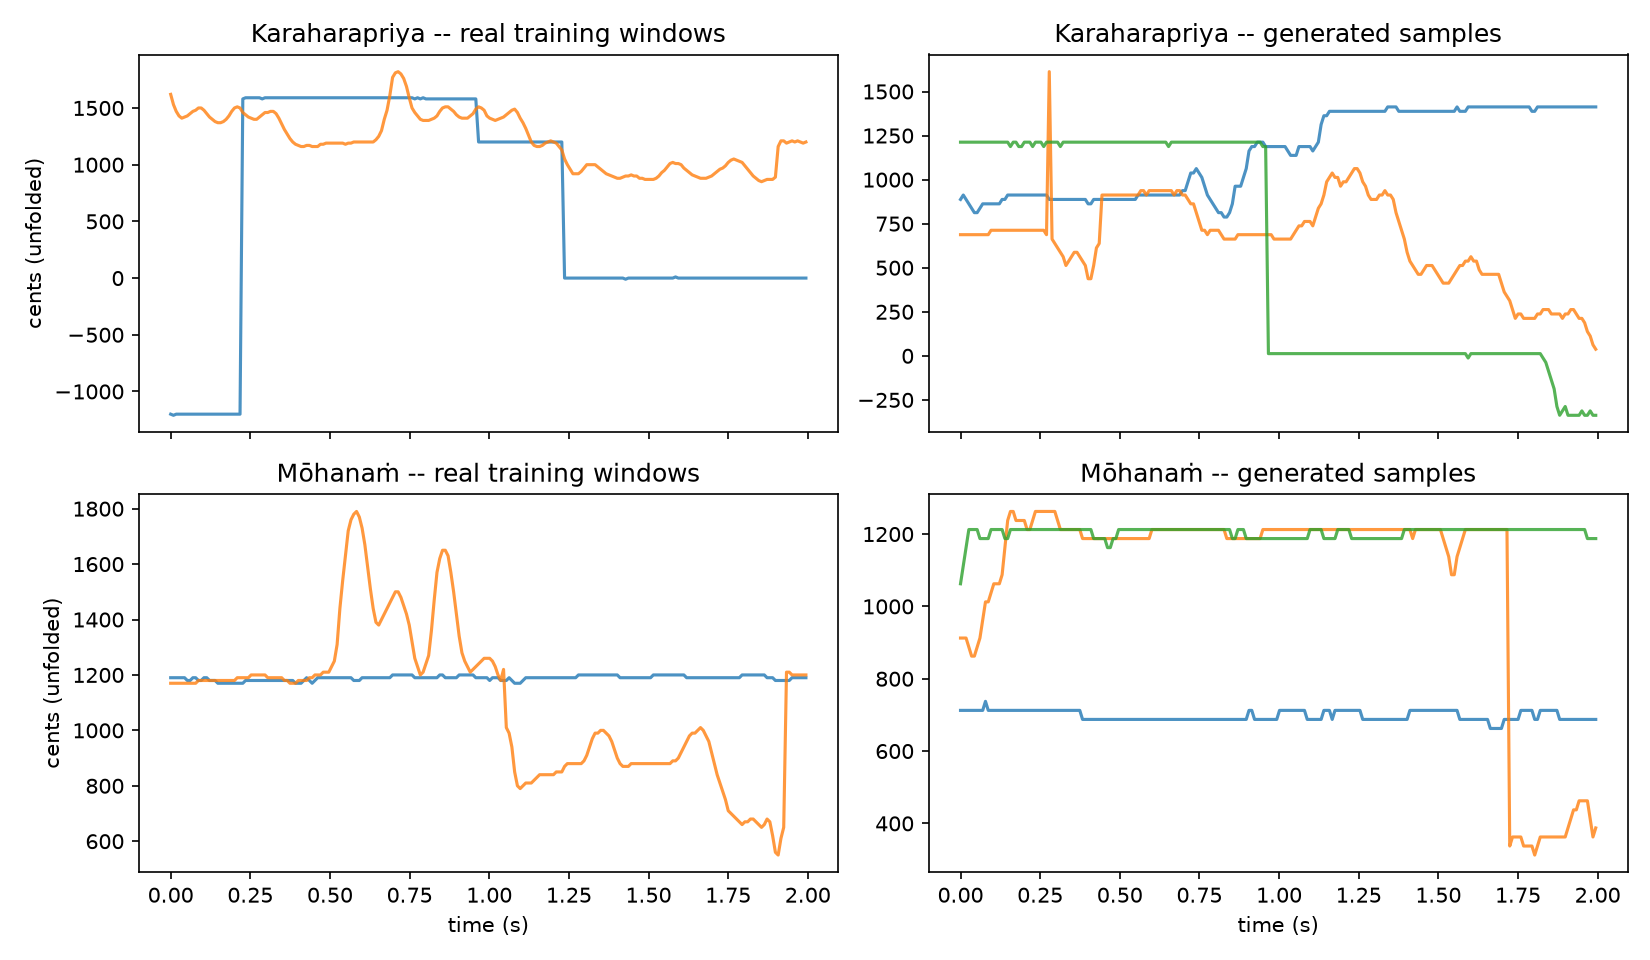

In [10]:
show("m4_generated_vs_real.png")

**Evaluation (M5), three checks, all against real windows/samples from the
same run — no stale artifacts:**

1. Folded pitch-class-histogram distance (generated vs. real, own- vs.
   other-raga, Jensen-Shannon).
2. Classifier-called-raga (M2's standard config, fresh fit scoped to this
   generator's window length — M2's own fitted models weren't persisted).
3. Nearest-neighbour memorisation check against a real-to-real baseline.

Histogram distance (Jensen-Shannon, generated vs. real):


,bin_width,raga,js_to_own_real,js_to_other_real,discriminative_gap
0,10,Karaharapriya,0.6179,0.6173,-0.0006
1,10,Mōhanaṁ,0.6275,0.6469,0.0193
2,20,Karaharapriya,0.3219,0.3760,0.0541
3,20,Mōhanaṁ,0.3838,0.3865,0.0027
4,50,Karaharapriya,0.2433,0.2937,0.0503
5,50,Mōhanaṁ,0.3069,0.3177,0.0108
6,100,Karaharapriya,0.2094,0.2542,0.0448
7,100,Mōhanaṁ,0.2827,0.2925,0.0097


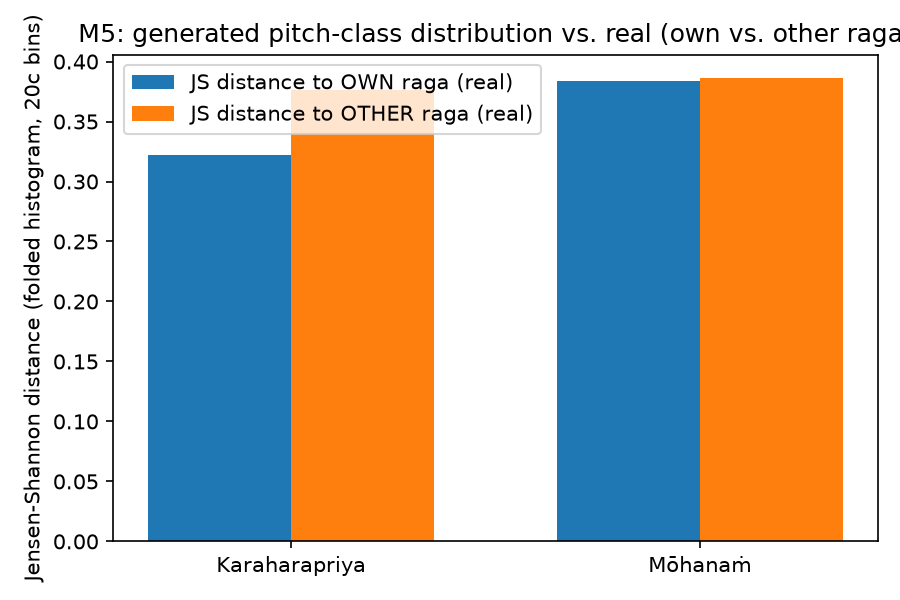

In [11]:
m5 = N["m5"]
HIST = pd.DataFrame(m5["histogram_distance"])
print("Histogram distance (Jensen-Shannon, generated vs. real):")
display(HIST.round(4))
show("m5_histogram_distance.png", width=500)

In [12]:
JUDGE = pd.DataFrame(m5["judge_classifier"]["results"])
print("Classifier-called-raga (chance = 0.5; 'real ceiling' = judge's own artist-grouped CV accuracy on real data):")
display(JUDGE.round(3))

Classifier-called-raga (chance = 0.5; 'real ceiling' = judge's own artist-grouped CV accuracy on real data):


,bin_width,raga,judge_call_accuracy,n_generated,real_artist_grouped_cv_bal_acc,cv_n_splits
0,10,Karaharapriya,0.167,6,0.601,2
1,10,Mōhanaṁ,1.000,6,0.601,2
2,20,Karaharapriya,0.833,6,0.591,2
3,20,Mōhanaṁ,0.667,6,0.591,2
4,50,Karaharapriya,0.833,6,0.578,2
5,50,Mōhanaṁ,0.500,6,0.578,2
6,100,Karaharapriya,0.833,6,0.576,2
7,100,Mōhanaṁ,0.500,6,0.576,2


Real-to-real NN baseline: median=161.9c, min=7.1c (n=200)
Generated-to-real NN: median=149.3c, min=13.9c (n=12)


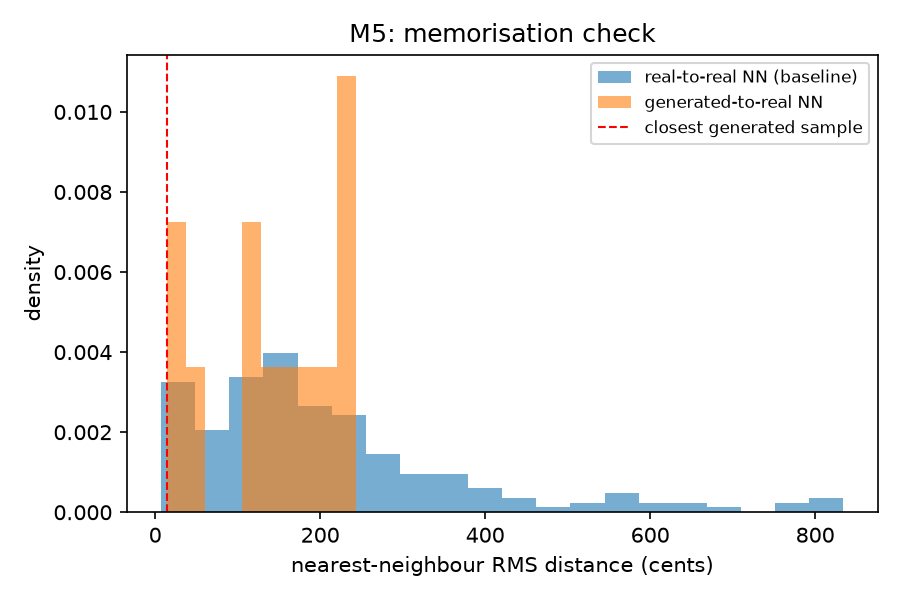

In [13]:
mc = m5["memorisation_check"]
print(f"Real-to-real NN baseline: median={mc['real_to_real_nn_baseline_median_cents']:.1f}c, "
      f"min={mc['real_to_real_nn_baseline_min_cents']:.1f}c (n={mc['n_real_baseline_sampled']})")
print(f"Generated-to-real NN: median={mc['generated_to_real_nn_median_cents']:.1f}c, "
      f"min={mc['generated_to_real_nn_min_cents']:.1f}c (n={mc['n_generated_checked']})")
show("m5_memorisation_check.png", width=500)

**Honest synthesis (from `status/STATUS_M5.md`), stated plainly:**
Karaharapriya generation shows real raga-conditioning signal across all three
checks. Mōhanaṁ generation does not clearly show the same — weak histogram
gap, judge accuracy swinging between perfect and chance depending on
resolution, and its closest real match by nearest-neighbour is from the
*other* raga. Consistent across three independent methods, so worth taking
seriously. No evidence of memorisation in either raga (generated-to-real
distances sit in the same range as real-to-real distances).

Every number here is over 6 generated samples and 2 real recordings per raga —
a proof-of-concept, not a benchmark result.

**Interpretation (hypothesis, not a verified explanation).** Documented
theory offers a partial account of the Karaharapriya/Mōhanaṁ asymmetry.
[Karaharapriya](https://en.wikipedia.org/wiki/Kharaharapriya) (22nd melakarta)
is described as having "swaras quite evenly spaced," with "several different
types of gamakas allowed" spread across its full 7-note scale — a wide
ornamentation vocabulary distributed over more scale degrees. Mōhanaṁ, while
also documented as gamaka-dependent on every note (§2 above), is pentatonic —
only 5 scale degrees for a *folded pitch-class histogram* (what both the M5
judge classifier and the histogram-distance check actually operate on) to
spread mass across, and derived from a different parent scale (Harikāmbhōji)
than Karaharapriya's. A 5-note distribution may simply have less structural
room to separate itself from a 7-note raga's distribution than two 7-note
ragas would from each other, independent of how well the generator itself
learned the ornamentation. **This is a plausible hypothesis consistent with
documented theory, not a verified explanation** — nobody has decomposed the
two ragas' histograms directly to test it, and the report should present it
as an open hypothesis, not a finding.

---
## 5. Limitations

Stated directly, not softened:

- **Artist confound.** Every raga-level classification result must be read
  alongside its artist composition. The quantisation spine (§2) dilutes this
  across ~12–40 ragas and many artists, and has artist-grouped CV variants —
  but the alapana-only config (4 ragas) and the entire generator (§5, 2
  ragas) rely on only 2 artists per raga.
- **Composition confound**, for metered sections only: two recordings of the
  same kriti teach the song, not the raga. Handled via composition-grouped CV
  and exclusion of composition-degenerate ragas in the primary M2 pool;
  alapana is exempt by construction (unmetered).
- **No leave-one-artist-out check ever ran for an allied pair** (§4) — no pair
  survived the balance constraint to run it on.
- **Mix vs. vocal pitch source.** `pitch.txt` (mix) and `pitch-vocal.txt`
  (isolated vocal) run at measurably different frame rates (~225 Hz vs.
  ~344.5 Hz) and different cleanliness. `dgm_utils.read_pitch()` measures fps
  per file rather than assuming a constant, but the two sources are not
  acoustically identical, and the raga pool mixes both.
- **Residual octave-tracking errors.** `clean_octave_outliers` catches
  *isolated* octave spikes via a local-median filter; it does not catch a
  *sustained* octave-tracking error that persists long enough to drag the
  local median with it. At least one such artifact is visible in the M4/M5
  generator's real training data and appears to have been partially learned
  by the model (see `status/STATUS_M4.md`).
- **Tiny corpus, single dataset.** Saraga Carnatic 1.5 only; the alapana-only
  corpus is 8 segments across 4 ragas; the generator trains on 2 recordings
  per raga. Every number in this report should be read as suggestive at this
  scale, not as a benchmark result.
- **Generator quantisation.** The generator's output is blocky at the 25-cent
  bin-width scale by construction (§5) — a disclosed representational
  limitation of the AR-over-quantised-pitch design, not a training artifact.
- **Licence.** CC BY-NC-SA 4.0 — non-commercial, share-alike, attribution
  required. See §6.

---
## 6. Licence & data note

**Saraga Carnatic Music Dataset 1.5**, Zenodo record
[4301737](https://zenodo.org/record/4301737), licensed **CC BY-NC-SA 4.0**.
Non-commercial use only, per the licence; only the text pitch/section/metadata annotations were
used, not the audio. Any reuse of this project's derived corpora or figures
must retain attribution and the share-alike/non-commercial terms.

---
## 7. Reproduction

- `requirements.txt` pins the exact package versions this project was
  verified against (numpy, pandas, scikit-learn, scipy, matplotlib, torch,
  nbformat, nbclient, ipykernel).
- Each notebook sets `DATA_ROOT` from a candidate-path list (local Windows
  path first, `/kaggle/input/...` fallback) — no manual edits needed to
  switch environments, beyond uploading the annotations as a Kaggle dataset.
- Run order: `00_data_audit` → `01_corpus_build` → `02_quantisation_study` →
  `03_allied_pair` → `04_generator` → this notebook. Each writes its outputs
  to `artifacts/` (figures, CSVs, `numbers.json`) for the next to read; none
  require re-running an earlier notebook's modelling to produce their own
  numbers, except `02`/`03`/`04`/`05` reading `01`'s corpus and `02`'s CSVs
  respectively.

In [14]:
with open(os.path.join(ART, "numbers.json"), encoding="utf-8") as f:
    NUMBERS = json.load(f)
NUMBERS["m6"] = {
    "status": "report assembled",
    "milestones_present": [k for k in NUMBERS.keys() if k != "m6"],
    "requirements_pinned": True,
}
with open(os.path.join(ART, "numbers.json"), "w", encoding="utf-8") as f:
    json.dump(NUMBERS, f, indent=2, ensure_ascii=False)
print("wrote numbers.json[m6]")

wrote numbers.json[m6]
